## Import Libraries

In [11]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from pathlib import Path
import os

## Configuration and File Paths

In [12]:
STATION_ID = 1
CLEAN_PATH = f"./Station{STATION_ID}_cleaned_data.csv"
MISSING_PATH = f"./Station{STATION_ID}_missing_data.csv"
OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)

## Load and Prepare Data

In [13]:
df = pd.read_csv(CLEAN_PATH, parse_dates=True, index_col=0)
df.index = pd.to_datetime(df.index)
df.index.freq = 'h'

gap_df = pd.read_csv(MISSING_PATH, parse_dates=["Start Timestamp", "End Timestamp"])
SELECTED_COLS = [col for col in df.columns if col != 'Flag']

## Filter and Fill 1-24 Hour Gaps

In [14]:
gap_df["Number Missing"] = pd.to_numeric(gap_df["Number Missing"], errors="coerce")
gap_df = gap_df[gap_df["Number Missing"] <= 24]

log = []

for col in SELECTED_COLS:
    gaps = gap_df[gap_df["Parameter"] == col]
    for _, row in gaps.iterrows():
        start, end = row["Start Timestamp"], row["End Timestamp"]
        idx = pd.date_range(start, end, freq='h')
        df.loc[idx, col] = np.nan
        df[col] = df[col].interpolate(method="pchip")
        for ts in idx:
            log.append({
                "Station": STATION_ID,
                "Parameter": col,
                "Timestamp": ts,
                "Filled": df.loc[ts, col]
            })

pd.DataFrame(log).to_csv(OUT_DIR / f"Station{STATION_ID}_shortgap_fill_detail.csv", index=False)
df.reset_index().to_csv(OUT_DIR / f"Station{STATION_ID}_filled_shortgaps.csv", index=False)

## Reload Interpolated Data

In [15]:
df = pd.read_csv(OUT_DIR / f"Station{STATION_ID}_filled_shortgaps.csv")
if 'index' in df.columns and 'Timestamp' not in df.columns:
    df.rename(columns={'index': 'Timestamp'}, inplace=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index("Timestamp", inplace=True)


## Evaluate kNN Imputation

In [16]:
metrics = []

for col in SELECTED_COLS:
    missing_idx = []
    true_vals = []
    gaps = gap_df[gap_df["Parameter"] == col]
    
    for _, row in gaps.iterrows():
        idx = pd.date_range(row["Start Timestamp"], row["End Timestamp"], freq="h")
        idx = [i for i in idx if i in df.index]
        if idx:
            missing_idx.extend(idx)
            true_vals.extend(df.loc[idx, col])
            df.loc[idx, col] = np.nan

    if len(true_vals) < 3:
        print(f" Not enough data to evaluate {col}")
        continue

    temp = df.copy()

    if col == 'Wind direction':
        temp["Wind_sin"] = np.sin(np.deg2rad(temp[col]))
        temp["Wind_cos"] = np.cos(np.deg2rad(temp[col]))
        impute_cols = ["Wind_sin", "Wind_cos"] + [c for c in SELECTED_COLS if c != "Wind direction"]
    else:
        impute_cols = SELECTED_COLS.copy()

    X = temp[impute_cols].dropna(how='all')
    imputer = KNNImputer(n_neighbors=5)
    imputed = imputer.fit_transform(X)
    imputed_df = pd.DataFrame(imputed, columns=[f"{c}_knn" for c in impute_cols], index=X.index)

    temp = temp.drop(columns=imputed_df.columns, errors='ignore')
    temp = pd.concat([temp, imputed_df], axis=1)

    if col == 'Wind direction':
        sin_pred = temp.loc[missing_idx, "Wind_sin_knn"]
        cos_pred = temp.loc[missing_idx, "Wind_cos_knn"]
        pred = np.rad2deg(np.arctan2(sin_pred, cos_pred)) % 360
    else:
        pred = temp.loc[missing_idx, f"{col}_knn"]

    mse = mean_squared_error(true_vals, pred)
    mae = mean_absolute_error(true_vals, pred)
    rmse = np.sqrt(mse)
    metrics.append({"Variable": col, "MSE": mse, "MAE": mae, "RMSE": rmse})

    print(f"{col}: MSE={mse:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
    temp.to_csv(OUT_DIR / f"Station{STATION_ID}_{col}_knn_eval.csv")


SWC_5: MSE=0.002, MAE=0.033, RMSE=0.040
SWC_10: MSE=0.001, MAE=0.029, RMSE=0.032
SWC_20: MSE=0.001, MAE=0.027, RMSE=0.033
SWC_50: MSE=0.000, MAE=0.013, RMSE=0.014
T_5: MSE=20.155, MAE=4.086, RMSE=4.489
T_10: MSE=19.660, MAE=3.917, RMSE=4.434
T_20: MSE=29.181, MAE=4.972, RMSE=5.402
T_50: MSE=33.798, MAE=5.637, RMSE=5.814
Tair: MSE=18.351, MAE=3.658, RMSE=4.284
RH: MSE=1031.669, MAE=21.227, RMSE=32.120
Wind speed: MSE=2.426, MAE=1.429, RMSE=1.557
Wind direction: MSE=7641.830, MAE=50.031, RMSE=87.418
Srad: MSE=8856.745, MAE=81.932, RMSE=94.110
Ppt: MSE=0.000, MAE=0.000, RMSE=0.000


## Save Metric Summary

In [17]:
pd.DataFrame(metrics).to_csv(OUT_DIR / f"Station{STATION_ID}_kNN_metrics_summary.csv", index=False)
print(" All done. Summary saved.")

 All done. Summary saved.


## Plot Original vs kNN Imputed

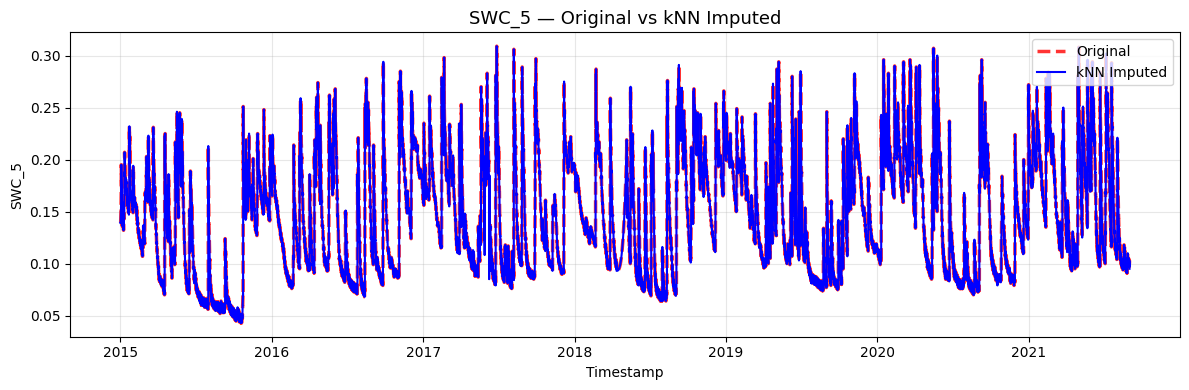

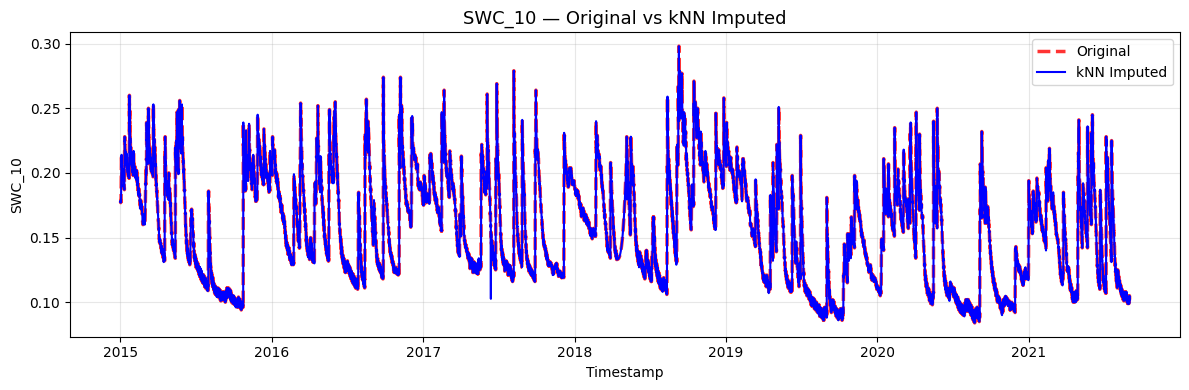

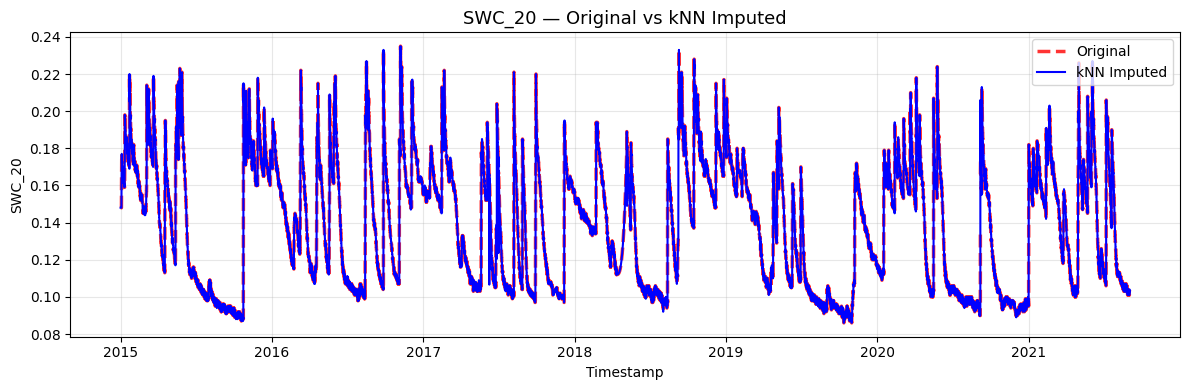

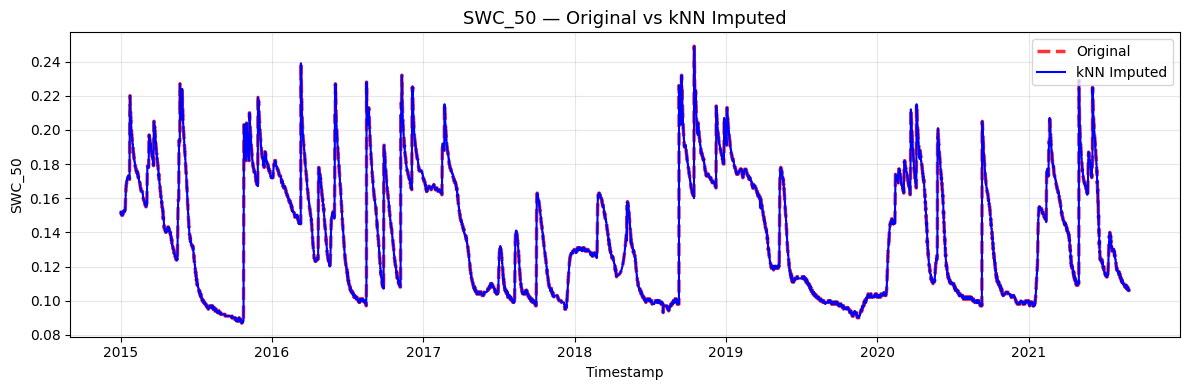

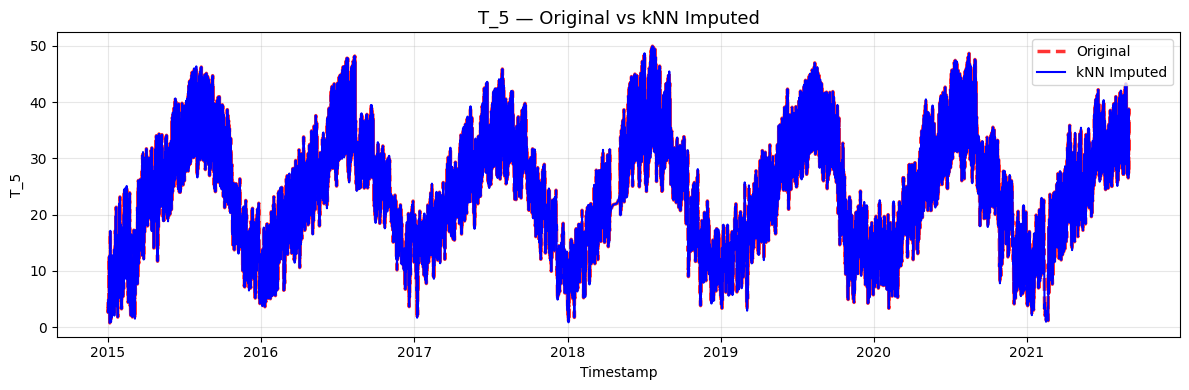

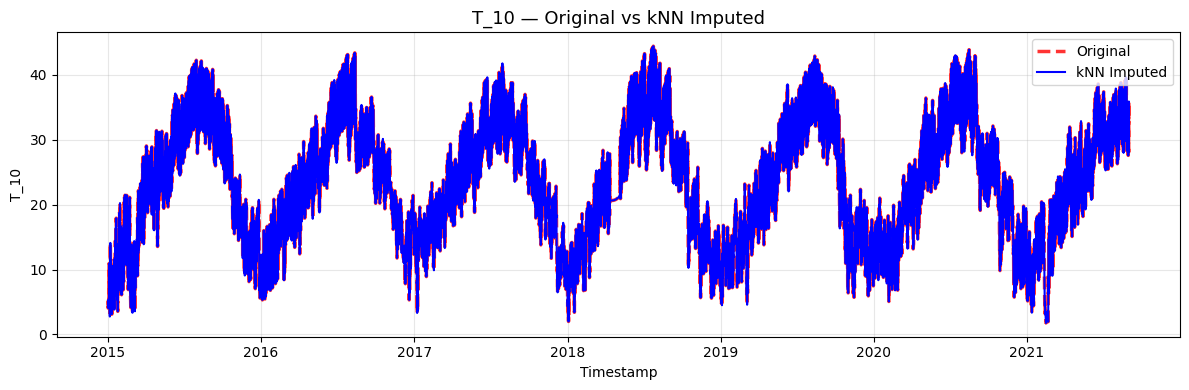

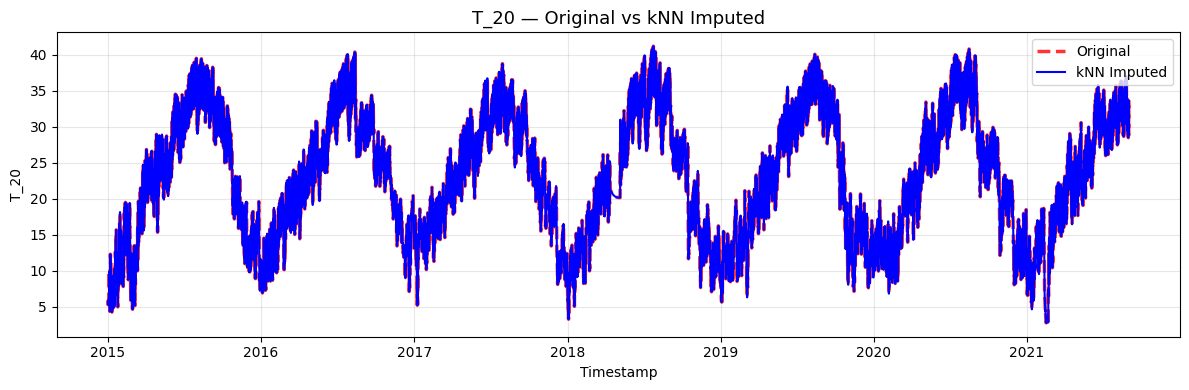

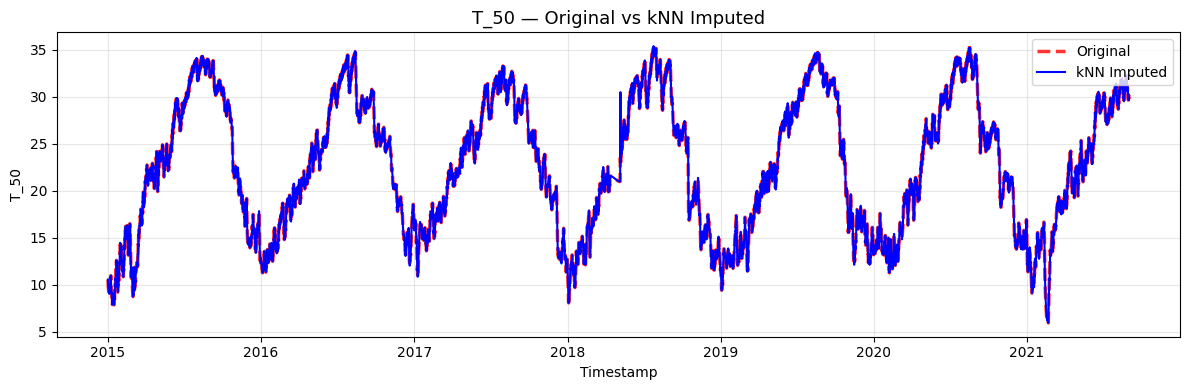

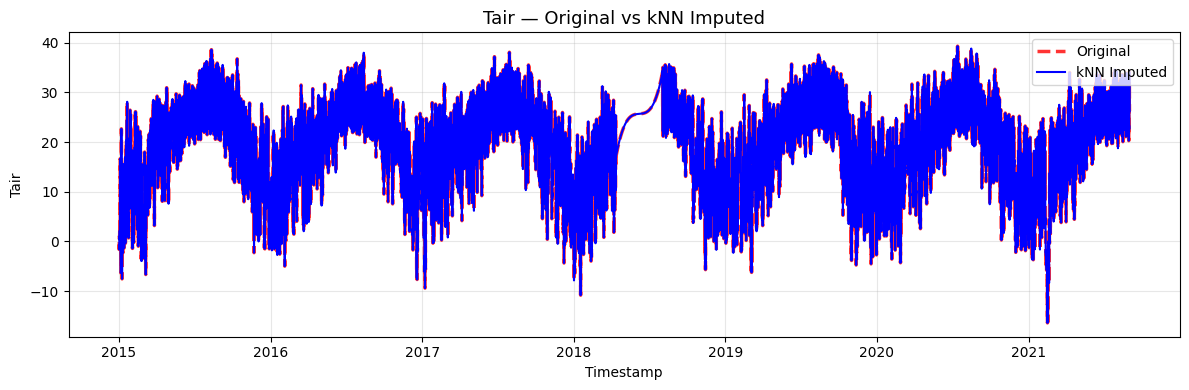

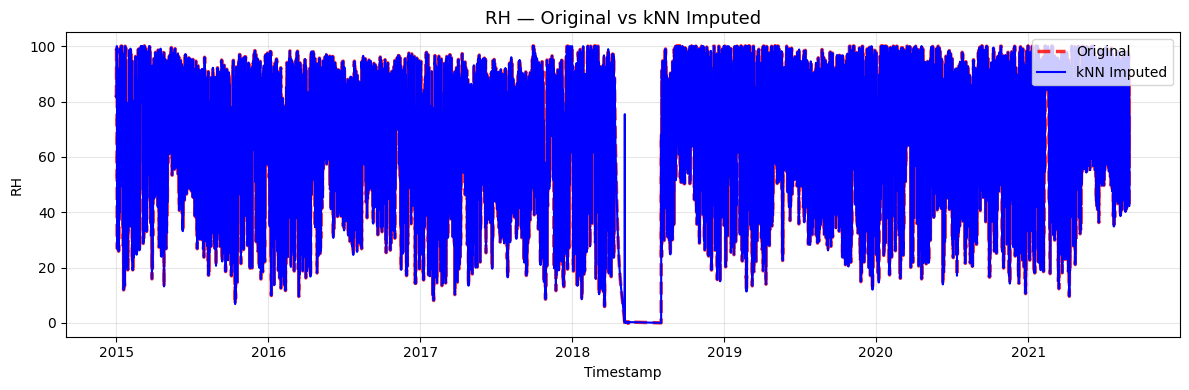

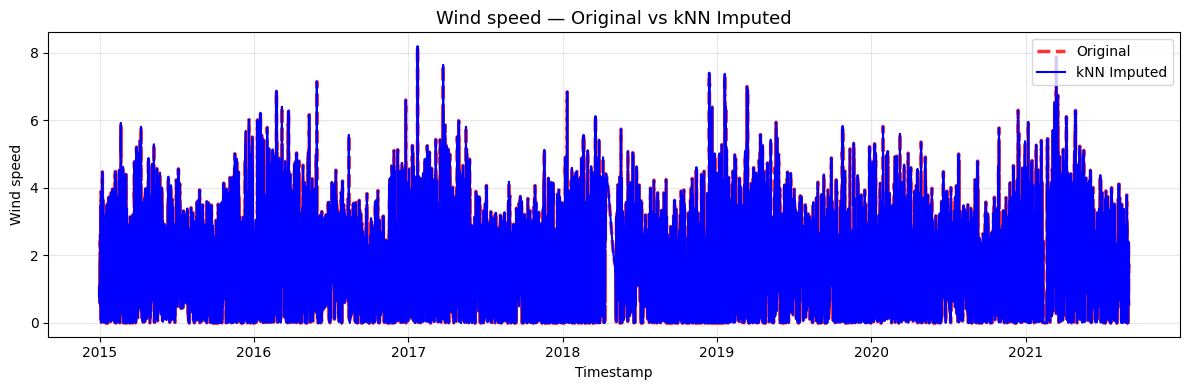

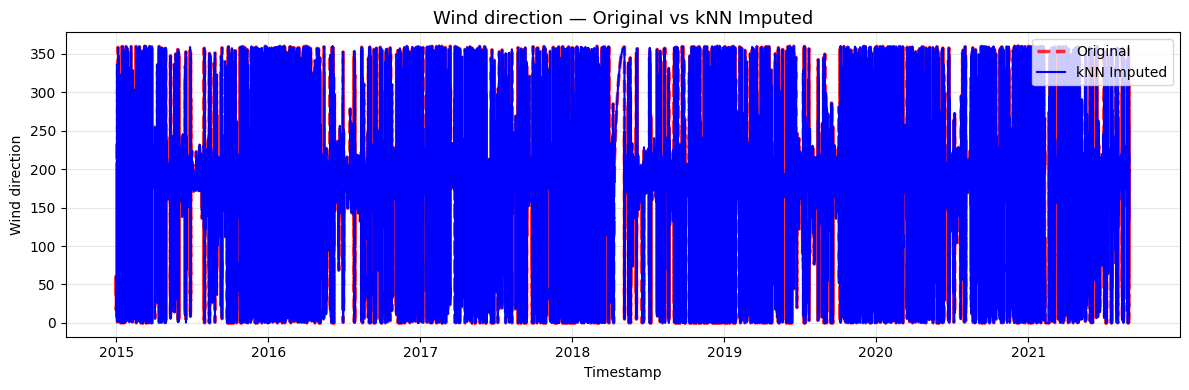

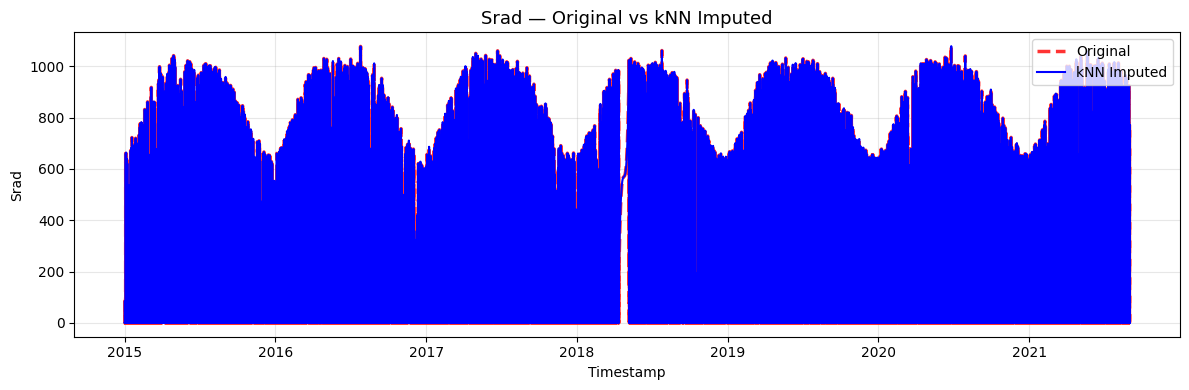

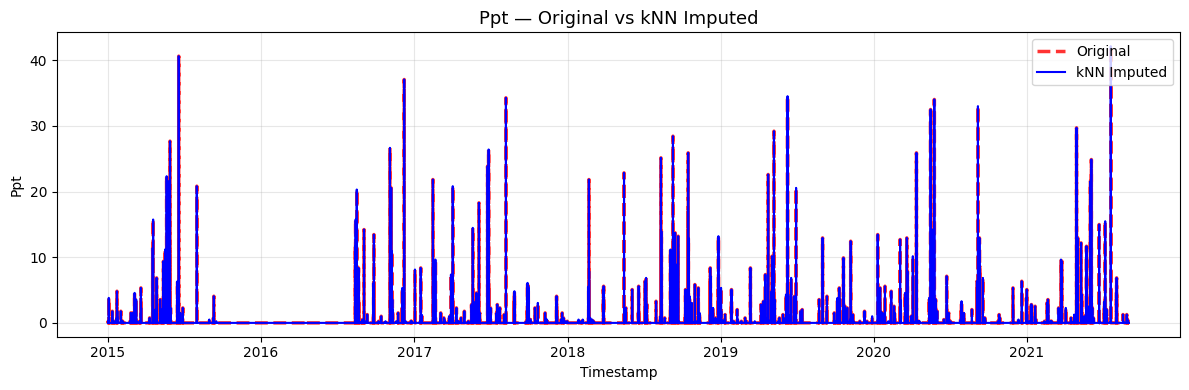

In [19]:
for col in SELECTED_COLS:
    eval_path = OUT_DIR / f"Station{STATION_ID}_{col}_knn_eval.csv"
    if not eval_path.exists():
        print(f"⚠️ File not found: {eval_path}")
        continue

    df_eval = pd.read_csv(eval_path, parse_dates=["Timestamp"])
    df_eval.set_index("Timestamp", inplace=True)

    plt.figure(figsize=(12, 4))
    
    # Original: red dashed line, thicker
    plt.plot(df_eval.index, df_eval[col], color='red', label="Original", linewidth=2.5, linestyle='--', alpha=0.8)
    
    if col == 'Wind direction':
        sin_pred = df_eval["Wind_sin_knn"]
        cos_pred = df_eval["Wind_cos_knn"]
        knn_decoded = np.rad2deg(np.arctan2(sin_pred, cos_pred)) % 360
        plt.plot(df_eval.index, knn_decoded, color='blue', label="kNN Imputed", linewidth=1.5)
    else:
        plt.plot(df_eval.index, df_eval[f"{col}_knn"], color='blue', label="kNN Imputed", linewidth=1.5)

    plt.title(f"{col} — Original vs kNN Imputed", fontsize=13)
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
